<a href="https://colab.research.google.com/github/marco-la-rosa/tox21-toxicity-ML-classification/blob/main/tox21-toxicity-ML-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Standard libraries
import os
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Chemistry / RDKit
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, rdFingerprintGenerator, Descriptors

# Visualization
import seaborn as sns
from matplotlib import pyplot as plt

# Machine Learning - feature selection
from sklearn.feature_selection import VarianceThreshold

# Machine Learning - model selection
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# Machine Learning - models
from sklearn.linear_model import LogisticRegression


from sklearn.impute import SimpleImputer
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler

In [10]:
def save_plot(name, path="../results/plots"):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    plt.savefig(path / f"{name}.png", dpi=300, bbox_inches="tight")

# **Dataset preparation**

In [11]:
!wget -P ../data/raw https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz

tox21_df = pd.read_csv("../data/raw/tox21.csv.gz")
tox21_df.head()

--2026-04-18 04:28:45--  https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving deepchemdata.s3-us-west-1.amazonaws.com (deepchemdata.s3-us-west-1.amazonaws.com)... 52.219.194.26, 16.15.4.168, 52.219.112.201, ...
Connecting to deepchemdata.s3-us-west-1.amazonaws.com (deepchemdata.s3-us-west-1.amazonaws.com)|52.219.194.26|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122925 (120K) [application/x-gzip]
Saving to: ‘../data/raw/tox21.csv.gz.1’

tox21.csv.gz.1      100%[===================>] 120.04K   334KB/s    in 0.4s    

2026-04-18 04:28:46 (334 KB/s) - ‘../data/raw/tox21.csv.gz.1’ saved [122925/122925]



,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


The dataset contains the outputs of 12 different toxicity bioassays and the ID and the SMILES of the molecules tested.


*   0 means that the bioassay has determined that the molecule is not toxic
*   1 means that the bioassay has determined that the molecule is toxic

We are gonna extract later the features from the SMILES of the molecules


In [12]:
print(f"Dimensioni del dataframe prima della pulizia: {tox21_df.shape}")

Dimensioni del dataframe prima della pulizia: (7831, 14)


We need to filter the molecules that cannot be processed by the function Chem.MolFromSmiles from the rdkit library

In [13]:
df = tox21_df[tox21_df['smiles'].apply(lambda x: Chem.MolFromSmiles(x) is not None)].reset_index(drop=True)
df.head()

[04:28:47] WARNING: not removing hydrogen atom without neighbors
[04:28:47] Explicit valence for atom # 8 Al, 6, is greater than permitted
[04:28:47] Explicit valence for atom # 3 Al, 6, is greater than permitted
[04:28:47] Explicit valence for atom # 4 Al, 6, is greater than permitted
[04:28:47] Explicit valence for atom # 4 Al, 6, is greater than permitted
[04:28:47] Explicit valence for atom # 9 Al, 6, is greater than permitted
[04:28:47] Explicit valence for atom # 5 Al, 6, is greater than permitted
[04:28:47] Explicit valence for atom # 16 Al, 6, is greater than permitted
[04:28:48] Explicit valence for atom # 20 Al, 6, is greater than permitted


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [14]:
print(f"Dimensioni del dataframe dopo la pulizia: {df.shape}")

Dimensioni del dataframe dopo la pulizia: (7823, 14)


It contains 7823 molecules.

In [15]:
df["mol_id"].nunique()

7823

All molecules are different.

Example of random 3 molecules:


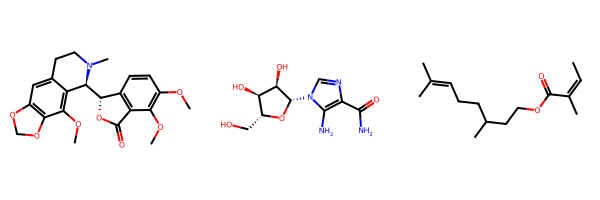

In [16]:
print("Example of random 3 molecules:")

mols = [Chem.MolFromSmiles(s) for s in df["smiles"].sample(n=3)]
Draw.MolsToGridImage(mols)

In [17]:
df.columns

Index(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
       'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53',
       'mol_id', 'smiles'],
      dtype='str')

In [18]:
assays = df.columns[:-2]

print("The bioassays are: ")
for i in range(len(assays)):
  print(f"{i+1}. {assays[i]}")

The bioassays are: 
1. NR-AR
2. NR-AR-LBD
3. NR-AhR
4. NR-Aromatase
5. NR-ER
6. NR-ER-LBD
7. NR-PPAR-gamma
8. SR-ARE
9. SR-ATAD5
10. SR-HSE
11. SR-MMP
12. SR-p53


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7823 entries, 0 to 7822
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7258 non-null   float64
 1   NR-AR-LBD      6751 non-null   float64
 2   NR-AhR         6542 non-null   float64
 3   NR-Aromatase   5815 non-null   float64
 4   NR-ER          6186 non-null   float64
 5   NR-ER-LBD      6948 non-null   float64
 6   NR-PPAR-gamma  6443 non-null   float64
 7   SR-ARE         5825 non-null   float64
 8   SR-ATAD5       7065 non-null   float64
 9   SR-HSE         6460 non-null   float64
 10  SR-MMP         5804 non-null   float64
 11  SR-p53         6767 non-null   float64
 12  mol_id         7823 non-null   str    
 13  smiles         7823 non-null   str    
dtypes: float64(12), str(2)
memory usage: 855.8 KB


In [20]:
missing = df.isnull().sum()
missing_perc = df.isnull().mean() * 100
missing_df = pd.DataFrame({"Missing": missing, "Missing %": missing_perc})
print((missing_df).to_string())

               Missing  Missing %
NR-AR              565   7.222293
NR-AR-LBD         1072  13.703183
NR-AhR            1281  16.374792
NR-Aromatase      2008  25.667902
NR-ER             1637  20.925476
NR-ER-LBD          875  11.184967
NR-PPAR-gamma     1380  17.640291
SR-ARE            1998  25.540074
SR-ATAD5           758   9.689377
SR-HSE            1363  17.422984
SR-MMP            2019  25.808513
SR-p53            1056  13.498658
mol_id               0   0.000000
smiles               0   0.000000


It contains many missing values in the outputs, while it contains the IDs and the SMILES of all the molecules. Since the missing values are just in the outputs changing them would be a serious error because it could introduce very large bias.

## **Class distribution**

In [21]:
df.iloc[:, :-2].skew()

NR-AR            4.540680
NR-AR-LBD        5.053015
NR-AhR           2.377779
NR-Aromatase     4.055393
NR-ER            2.229239
NR-ER-LBD        4.119287
NR-PPAR-gamma    5.628878
SR-ARE           1.838017
SR-ATAD5         4.879579
SR-HSE           3.799131
SR-MMP           1.874070
SR-p53           3.615260
dtype: float64

All the targets show a strong positive skewness. This means there is a class imbalance. This is typical in real-world toxicity screening datasets.

In [22]:
counts = []
for column in df.columns[:-2]:
  not_toxic = (df[column] == 0).sum()
  toxic = (df[column] == 1).sum()
  total = not_toxic + toxic

  not_toxic_perc = (not_toxic / total * 100) if total > 0 else 0
  toxic_perc = (toxic / total * 100) if total > 0 else 0

  counts.append({
      "Test": column,
      "Not Toxic": not_toxic,
      "Toxic": toxic,
      "Not Toxic %": f"{not_toxic_perc:.2f}%",
      "Toxic %": f"{toxic_perc:.2f}%"
  })

counts_df = pd.DataFrame(counts)
print(counts_df.to_string())

             Test  Not Toxic  Toxic Not Toxic % Toxic %
0           NR-AR       6950    308      95.76%   4.24%
1       NR-AR-LBD       6514    237      96.49%   3.51%
2          NR-AhR       5774    768      88.26%  11.74%
3    NR-Aromatase       5515    300      94.84%   5.16%
4           NR-ER       5395    791      87.21%  12.79%
5       NR-ER-LBD       6599    349      94.98%   5.02%
6   NR-PPAR-gamma       6257    186      97.11%   2.89%
7          SR-ARE       4883    942      83.83%  16.17%
8        SR-ATAD5       6801    264      96.26%   3.74%
9          SR-HSE       6088    372      94.24%   5.76%
10         SR-MMP       4886    918      84.18%  15.82%
11         SR-p53       6344    423      93.75%   6.25%


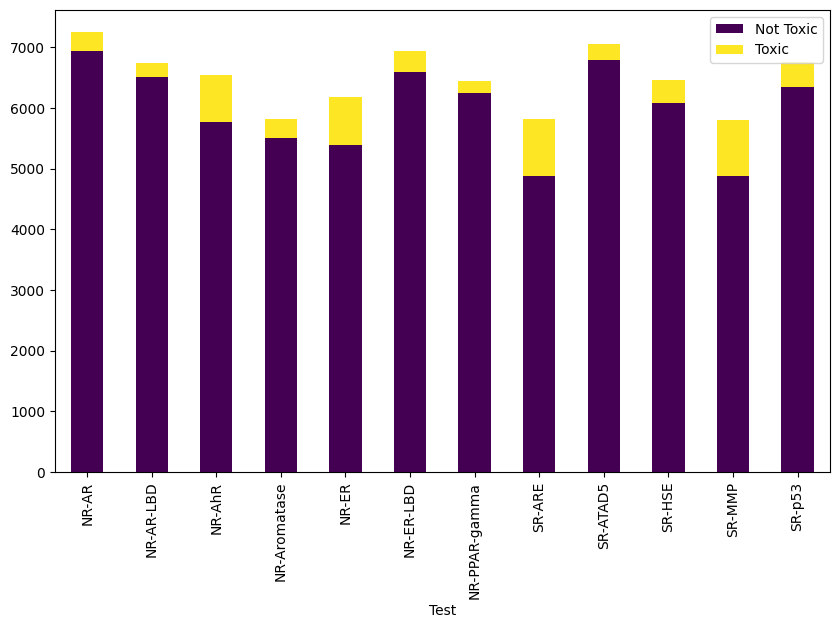

In [23]:
ax = counts_df.set_index("Test").plot.bar(stacked=True, figsize=(10, 6), colormap="viridis")
fig = ax.get_figure()
save_plot("class-distribution")
plt.show()

The output values are very largely skewed: there are few toxic molecules, while the majority of molecules are not toxic.
This means that it's very important to increase the recall because it's more important to correctly identify toxic molecules instead of misclassify non toxic molecules.
In other words: we should have as less false negatives as possible (this can be accomplished for example lowering the threshold in logistic regression)

## **Feature extraction**

In [24]:
desc_names = [x[0] for x in Descriptors.descList]
desc_funcs = [x[1] for x in Descriptors.descList]

all_desc_values = []

for smiles in df["smiles"]:
  mol = Chem.MolFromSmiles(smiles)
  desc_values = [f(mol) for f in desc_funcs]
  all_desc_values.append(desc_values)

desc_df = pd.DataFrame(all_desc_values, columns=desc_names)
desc_df.head()

[04:28:49] WARNING: not removing hydrogen atom without neighbors
[04:28:49] WARNING: not removing hydrogen atom without neighbors


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.107593,11.107593,0.073011,-3.723219,0.900283,11.875000,258.324,248.244,258.013284,86,...,0,1,0,0,0,1,0,0,0,0
1,11.790004,11.790004,0.172500,-0.515139,0.738013,20.600000,204.229,192.133,204.089878,78,...,0,0,0,0,0,0,0,0,0,1
2,11.165775,11.165775,0.207144,-0.369724,0.666269,52.619048,288.475,256.219,288.245316,118,...,0,0,0,0,0,0,0,0,0,0
3,12.570517,12.570517,0.042633,-0.042633,0.822261,12.500000,276.424,248.200,276.220164,112,...,0,0,0,0,0,0,0,0,0,0
4,10.251875,10.251875,0.383488,-5.197724,0.365583,15.090909,206.027,197.963,205.974526,68,...,0,0,0,0,0,0,0,0,0,0


In [25]:
desc_df.shape

(7823, 217)

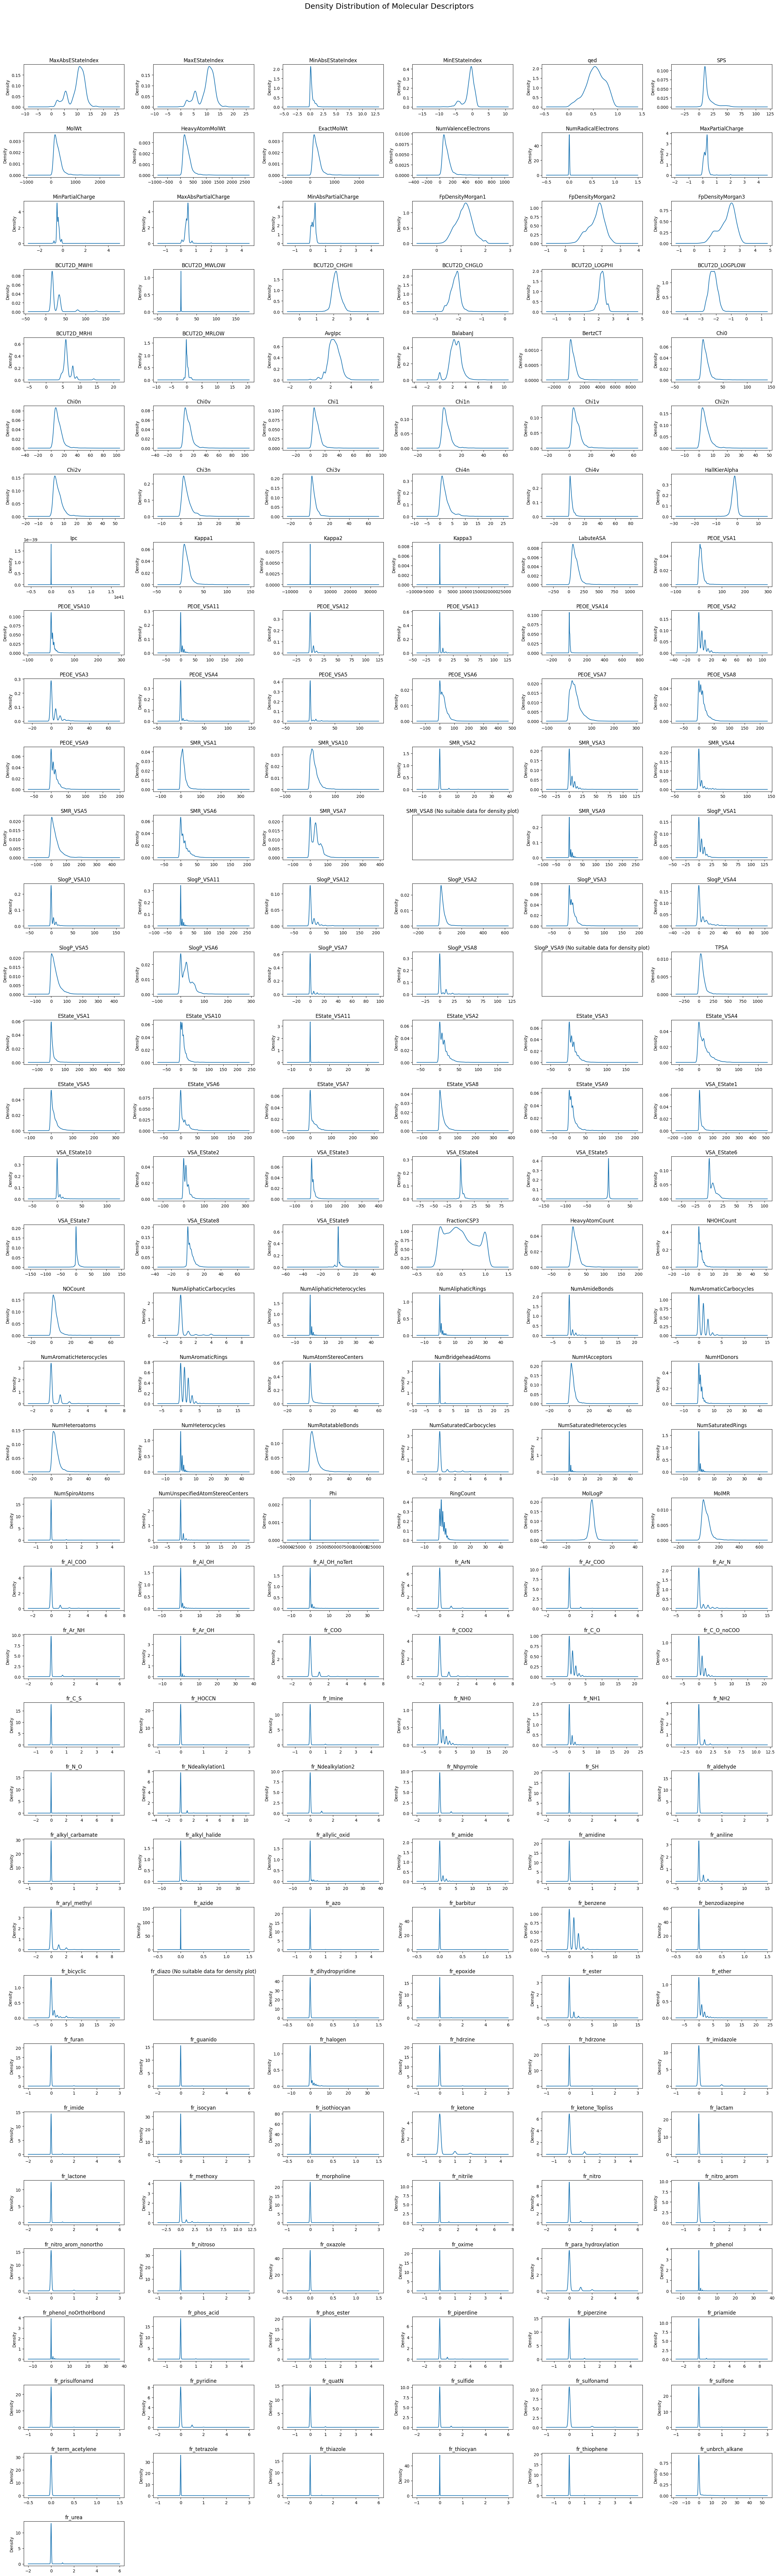

In [26]:
fig, axes = plt.subplots(nrows=37, ncols=6, figsize=(26, 84)) # Create figure and axes
axes = axes.flatten() # Flatten the 2D array of axes

# Plot density for each feature
features = desc_df.columns
for i, feature in enumerate(features):
    if i < len(axes): # Ensure there is an axis for the feature
        series_to_plot = desc_df[feature].replace([np.inf, -np.inf], np.nan).dropna() # Replace inf with NaN, then drop all NaN values from the feature series before plotting 
        if not series_to_plot.empty and len(series_to_plot.unique()) > 1: # Ensure there's data to plot and enough variation
            series_to_plot.plot(kind='density', ax=axes[i])
            axes[i].set_title(feature)
            axes[i].legend().remove() # Remove individual subplot legends to avoid clutter
        else:
            # If after dropping NaNs and infs, the series is empty or has no variation, just set a title
            axes[i].set_title(f"{feature} (No suitable data for density plot)")
            axes[i].set_xticks([])
            axes[i].set_yticks([])

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Density Distribution of Molecular Descriptors', y=1.02, fontsize=18)

save_plot("density-distribution-molecular-descriptors")
plt.show()

In [27]:
# Replace infinite values with NaN
desc_df_to_process = desc_df.replace([np.inf, -np.inf], np.nan)

# Impute NaN values with the median of each column
imputer = SimpleImputer(strategy='median')
desc_df_imputed_array = imputer.fit_transform(desc_df_to_process)
desc_df_imputed = pd.DataFrame(desc_df_imputed_array, columns=desc_df_to_process.columns)

# Correctly filter columns after VarianceThreshold
selector = VarianceThreshold(threshold=0.0)
desc_non_constant = selector.fit_transform(desc_df_imputed)

# Use get_feature_names_out to get only the names of the columns that were NOT dropped
remaining_columns = selector.get_feature_names_out()
desc_non_constant_df = pd.DataFrame(desc_non_constant, columns=remaining_columns)

la mediana è la migliore per dati skewed

In [28]:
desc_df.shape

(7823, 217)

In [29]:
desc_non_constant_df.shape

(7823, 214)

3 features removed (they were just noise)

In [30]:
threshold = 0.95

correlation = desc_non_constant_df.corr()
upper = np.triu(np.ones(correlation.shape), k=1).astype(bool)

high_corr_pairs = [
    (col, row, round(correlation.loc[row, col], 2))
    for col in correlation.columns
    for row in correlation.index
    if upper[correlation.index.get_loc(row), correlation.columns.get_loc(col)]
    and abs(correlation.loc[row, col]) > threshold
]

print("Highly correlated feature pairs (|corr| > 0.95):")
for a, b, val in high_corr_pairs:
    print(f"{a} - {b}: {val}")

Highly correlated feature pairs (|corr| > 0.95):
MaxEStateIndex - MaxAbsEStateIndex: 1.0
HeavyAtomMolWt - MolWt: 1.0
ExactMolWt - MolWt: 1.0
ExactMolWt - HeavyAtomMolWt: 1.0
NumValenceElectrons - MolWt: 0.96
NumValenceElectrons - ExactMolWt: 0.96
Chi0 - MolWt: 0.96
Chi0 - HeavyAtomMolWt: 0.95
Chi0 - ExactMolWt: 0.96
Chi0 - NumValenceElectrons: 1.0
Chi0n - NumValenceElectrons: 0.99
Chi0n - Chi0: 0.98
Chi0v - MolWt: 0.97
Chi0v - HeavyAtomMolWt: 0.96
Chi0v - ExactMolWt: 0.97
Chi0v - NumValenceElectrons: 0.98
Chi0v - Chi0: 0.98
Chi0v - Chi0n: 0.98
Chi1 - MolWt: 0.95
Chi1 - ExactMolWt: 0.95
Chi1 - NumValenceElectrons: 0.99
Chi1 - Chi0: 0.99
Chi1 - Chi0n: 0.98
Chi1 - Chi0v: 0.98
Chi1n - NumValenceElectrons: 0.98
Chi1n - Chi0: 0.97
Chi1n - Chi0n: 0.99
Chi1n - Chi0v: 0.97
Chi1n - Chi1: 0.98
Chi1v - NumValenceElectrons: 0.95
Chi1v - Chi0n: 0.96
Chi1v - Chi0v: 0.98
Chi1v - Chi1n: 0.95
Chi2n - NumValenceElectrons: 0.95
Chi2n - Chi0n: 0.97
Chi2n - Chi1n: 0.98
Chi2v - Chi1v: 0.97
Chi3n - Chi1n: 0.9

In [31]:
corr = desc_non_constant_df.corr().abs()

# distanza
dist = 1 - corr

# clustering gerarchico
condensed = squareform(dist)
linkage = hierarchy.linkage(condensed, method='average')

# taglio cluster
threshold = 0.1  # equivalente a corr > 0.9
clusters = hierarchy.fcluster(linkage, threshold, criterion='distance')

# scegli una feature per cluster
selected = []
for cluster_id in np.unique(clusters):
    members = corr.columns[clusters == cluster_id]
    selected.append(members[0])  # semplice heuristic

reduced_df = desc_non_constant_df[selected]
reduced_df.shape

(7823, 177)

we're clustering the similar features and selecting only one feature per cluster

In [32]:
scaler = StandardScaler()

desc_scaled_array = scaler.fit_transform(reduced_df)
desc_scaled_df = pd.DataFrame(desc_scaled_array, columns=reduced_df.columns)

desc_scaled_df.head()

print(f"Mean before: {desc_non_constant.mean():.2f} ")
print(f'Mean (should be ~0): {desc_scaled_array.mean():.2f}')
print(f"Std Dev before: {desc_non_constant.std():.2f}")
print(f'Std Dev (should be ~1): {desc_scaled_array.std():.2f}')

Mean before: 68242484288445339224311990396649472.00 
Mean (should be ~0): 0.00
Std Dev before: 88283118880041379234326824216202051584.00
Std Dev (should be ~1): 1.00


We're going to use Morgan Fingerprints extracted from the SMILES as features of the molecules.
These are binary-vectors (bits of 0s and 1s) where each bit corresponds to a fragment of the molecule.

In [33]:
mfp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

In [34]:
morgan_fingerprints = []
for smiles in df['smiles']:
    mol = Chem.MolFromSmiles(smiles)
    fp = list(mfp_gen.GetFingerprint(mol))
    morgan_fingerprints.append(fp)

column_names = [f"Morgan_Bit_{i+1}" for i in range(2048)]
morgan_fingerprints_df = pd.DataFrame(morgan_fingerprints, columns=column_names)

print(f"Generated fingerprints for {morgan_fingerprints_df.shape[0]} molecules.")
morgan_fingerprints_df.head()

[04:30:44] WARNING: not removing hydrogen atom without neighbors


Generated fingerprints for 7823 molecules.


,Morgan_Bit_1,Morgan_Bit_2,Morgan_Bit_3,Morgan_Bit_4,Morgan_Bit_5,Morgan_Bit_6,Morgan_Bit_7,Morgan_Bit_8,Morgan_Bit_9,Morgan_Bit_10,...,Morgan_Bit_2039,Morgan_Bit_2040,Morgan_Bit_2041,Morgan_Bit_2042,Morgan_Bit_2043,Morgan_Bit_2044,Morgan_Bit_2045,Morgan_Bit_2046,Morgan_Bit_2047,Morgan_Bit_2048
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Obviously, since the Morgan Fingerprints are representation of fragments of molecules via binary arrays, they don't need further exploratory data analysis such as correlation matrices or data scaling, but it could be useful to remove Morgan Bits that are 0 in every molecule since that's pretty much just noise.

In [35]:
selector = VarianceThreshold(threshold=0.0)
bits_selected = selector.fit_transform(morgan_fingerprints_df)

In [36]:
dropped_bits = 2048 - bits_selected.shape[1]
print(f"Feature Selection completed: {dropped_bits} bits removed (noise).")
print(f"Bits remaining: {bits_selected.shape[1]}")

Feature Selection completed: 0 bits removed (noise).
Bits remaining: 2048


Actually all bits in Morgan Fingerprints presents themselves at least once in this dataset, so there's 0 noise. This means that we have a very diverse set of molecules.

So we can just use the morgan_fingerprints_df

In [37]:
morgan_fingerprints_df.head()

,Morgan_Bit_1,Morgan_Bit_2,Morgan_Bit_3,Morgan_Bit_4,Morgan_Bit_5,Morgan_Bit_6,Morgan_Bit_7,Morgan_Bit_8,Morgan_Bit_9,Morgan_Bit_10,...,Morgan_Bit_2039,Morgan_Bit_2040,Morgan_Bit_2041,Morgan_Bit_2042,Morgan_Bit_2043,Morgan_Bit_2044,Morgan_Bit_2045,Morgan_Bit_2046,Morgan_Bit_2047,Morgan_Bit_2048
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


the fingerprints don't need feature selection, because they represent chemical substructures and we can't risk deleting some bits that could be useful in combination together. Selecting only some fingerprints means that every bit is indipendent, but that's not the chemical truth.

In [38]:
final_df = pd.concat([df, desc_scaled_df, morgan_fingerprints_df], axis=1)

print(f"Dimensioni final_df: {final_df.shape}")
final_df.head()

Dimensioni final_df: (7823, 2239)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,...,Morgan_Bit_2039,Morgan_Bit_2040,Morgan_Bit_2041,Morgan_Bit_2042,Morgan_Bit_2043,Morgan_Bit_2044,Morgan_Bit_2045,Morgan_Bit_2046,Morgan_Bit_2047,Morgan_Bit_2048
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
Path("../data/processed").mkdir(parents=True, exist_ok=True)

feature_columns = ['mol_id', 'smiles'] + list(reduced_df.columns) + list(morgan_fingerprints_df.columns)

for assay in assays:
    assay_specific_df = final_df[[assay] + feature_columns].dropna(subset=[assay])

    file_name = f"../data/processed/{assay}.csv"
    assay_specific_df.to_csv(file_name, index=False)
    print(f"Dataset salvato: {file_name} | Righe: {len(assay_specific_df)}")


Dataset salvato: ../data/processed/NR-AR.csv | Righe: 7258
Dataset salvato: ../data/processed/NR-AR-LBD.csv | Righe: 6751
Dataset salvato: ../data/processed/NR-AhR.csv | Righe: 6542
Dataset salvato: ../data/processed/NR-Aromatase.csv | Righe: 5815
Dataset salvato: ../data/processed/NR-ER.csv | Righe: 6186
Dataset salvato: ../data/processed/NR-ER-LBD.csv | Righe: 6948
Dataset salvato: ../data/processed/NR-PPAR-gamma.csv | Righe: 6443
Dataset salvato: ../data/processed/SR-ARE.csv | Righe: 5825
Dataset salvato: ../data/processed/SR-ATAD5.csv | Righe: 7065
Dataset salvato: ../data/processed/SR-HSE.csv | Righe: 6460
Dataset salvato: ../data/processed/SR-MMP.csv | Righe: 5804
Dataset salvato: ../data/processed/SR-p53.csv | Righe: 6767


In [45]:
df = pd.read_csv("../data/processed/NR-AR.csv")
df.head()

,NR-AR,mol_id,smiles,Kappa2,fr_N_O,fr_morpholine,fr_furan,fr_hdrzone,fr_hdrzine,fr_nitroso,...,Morgan_Bit_2039,Morgan_Bit_2040,Morgan_Bit_2041,Morgan_Bit_2042,Morgan_Bit_2043,Morgan_Bit_2044,Morgan_Bit_2045,Morgan_Bit_2046,Morgan_Bit_2047,Morgan_Bit_2048
0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,-0.020990,-0.061763,-0.098001,-0.101652,-0.081766,-0.098995,-0.066172,...,0,0,0,0,0,0,0,0,0,0
1,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O,-0.022064,-0.061763,-0.098001,-0.101652,-0.081766,-0.098995,-0.066172,...,0,0,0,0,0,0,0,0,0,0
2,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,-0.005268,-0.061763,-0.098001,-0.101652,-0.081766,-0.098995,-0.066172,...,0,0,0,0,0,0,0,0,0,0
3,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O,-0.026288,-0.061763,-0.098001,-0.101652,-0.081766,-0.098995,-0.066172,...,0,0,0,0,0,0,0,0,0,0
4,0.0,TOX5110,CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C,-0.010388,-0.061763,-0.098001,-0.101652,-0.081766,-0.098995,-0.066172,...,0,0,0,0,0,0,0,0,0,0


# **Feature Selection**

Facciamo training we're gonna do feature selection via regularization during the training

In [41]:
def split_dataset(assay_name):
  df = pd.read_csv(f"../data/processed/{assay_name}.csv")

  X = df.iloc[:, 3:]
  y = df[assay_name]

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
  return X_train, X_test, y_train, y_test

assay_splits = {}
for assay in assays:
  X_train, X_test, y_train, y_test = split_dataset(assay)
  assay_splits[assay] = {
      'X_train': X_train,
      'X_test': X_test,
      'y_train': y_train,
      'y_test': y_test
  }

In [42]:
print('NR-AR y_train value counts:')
print(assay_splits["NR-AR"]["y_train"].value_counts(normalize=True))
print('\nNR-AR y_test value counts:')
print(assay_splits["NR-AR"]["y_test"].value_counts(normalize=True))

NR-AR y_train value counts:
NR-AR
0.0    0.95763
1.0    0.04237
Name: proportion, dtype: float64

NR-AR y_test value counts:
NR-AR
0.0    0.9573
1.0    0.0427
Name: proportion, dtype: float64


In [49]:
# ========================
# IMPORT
# ========================
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    matthews_corrcoef,
    f1_score,
    classification_report
)

# ========================
# OUTPUT FOLDER
# ========================
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ========================
# MODELS CONFIG
# ========================
models_config = {

    "Logistic Regression": {
        'model': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('lr', LogisticRegression(
                solver='saga',
                max_iter=2000,
                class_weight='balanced'
            ))
        ]),
        'params': {
            'lr__C': [0.1, 1, 10],
            'lr__l1_ratio': [0, 0.5, 1]  # 0=L2, 1=L1
        }
    },

    "Support Vector Machine": {
        'model': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('svc', SVC(probability=True, class_weight='balanced'))
        ]),
        'params': {
            'svc__C': [0.1, 1, 10],
            'svc__kernel': ['linear', 'rbf']
        }
    },

    "Random Forest": {
        'model': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('rf', RandomForestClassifier(class_weight='balanced'))
        ]),
        'params': {
            'rf__n_estimators': [100, 300],
            'rf__max_depth': [10, 20, None]
        }
    },

    "XGBoost": {
        'model': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('xgb', XGBClassifier(
                eval_metric='logloss',
                use_label_encoder=False
            ))
        ]),
        'params': {
            'xgb__n_estimators': [100, 300],
            'xgb__max_depth': [3, 6],
            'xgb__learning_rate': [0.01, 0.1]
        }
    }
}

# ========================
# STORAGE
# ========================
all_detailed_results = []
all_assays_best_results = []

# ========================
# MAIN LOOP
# ========================
for assay_name in assays:
    print(f"\n>>> Processing Assay: {assay_name} <<<")

    X_train = assay_splits[assay_name]['X_train']
    y_train = assay_splits[assay_name]['y_train']
    X_test = assay_splits[assay_name]['X_test']
    y_test = assay_splits[assay_name]['y_test']

    # ---- imbalance (XGBoost) ----
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1

    best_score_for_assay = -1
    best_model_info = None
    best_report = ""

    for model_name, config in models_config.items():

        # aggiorna XGBoost dinamicamente
        if model_name == "XGBoost":
            config['model'].named_steps['xgb'].set_params(scale_pos_weight=scale_pos_weight)

        # ---- grid search ----
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=5,
            scoring='average_precision',
            n_jobs=-1,
            refit=True
        )

        grid_search.fit(X_train, y_train)
        model = grid_search.best_estimator_

        # ---- evaluation ----
        y_probs = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        ap = average_precision_score(y_test, y_probs)
        roc = roc_auc_score(y_test, y_probs)
        mcc = matthews_corrcoef(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        metrics = {
            'Assay': assay_name,
            'Model': model_name,
            'Avg Precision': ap,
            'ROC-AUC': roc,
            'F1 Score': f1,
            'MCC': mcc
        }

        all_detailed_results.append(metrics)

        print(f" - {model_name}: AP={ap:.3f}, ROC-AUC={roc:.3f}")

        # ---- best model ----
        if ap > best_score_for_assay:
            best_score_for_assay = ap
            best_model_info = metrics
            best_report = classification_report(y_test, y_pred)

    all_assays_best_results.append(best_model_info)

    print(f"\n🏆 BEST FOR {assay_name}: {best_model_info['Model']}")
    print(f"Avg Precision: {best_model_info['Avg Precision']:.4f} | ROC-AUC: {best_model_info['ROC-AUC']:.4f} | MCC: {best_model_info['MCC']:.4f}")
    print(f"Classification Report:\n{best_report}")

# ========================
# FINAL RESULTS
# ========================
best_summary_df = pd.DataFrame(all_assays_best_results)

print("\nSummary Table of Best Model per Assay:")
display(best_summary_df)

# ========================
# SAVE RESULTS
# ========================
best_summary_df.to_csv(RESULTS_DIR / "best_models_summary.csv", index=False)
best_summary_df.to_markdown(RESULTS_DIR / "best_models_summary.md", index=False)

print(f"\nResults saved in: {RESULTS_DIR}")


>>> Processing Assay: NR-AR <<<


KeyboardInterrupt: 